## 1. Setup and Imports

In [ ]:
import random
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Load Dataset and Explore Classes

In [ ]:
dataset_path = "/content/drive/MyDrive/brain-tumor-mri-dataset"
data_dir_pathlib = pathlib.Path(dataset_path)
print("Classes:", [item.name for item in data_dir_pathlib.iterdir() if item.is_dir()])

Classes: ['meningioma', 'pituitary', 'glioma', 'notumor']


In [ ]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Get class names and map them to integer labels
class_names = sorted([item.name for item in data_dir_pathlib.iterdir() if item.is_dir()])
class_to_label = {name: i for i, name in enumerate(class_names)}

# Load image paths and labels
all_image_paths = []
all_image_labels = []

for class_name in class_names:
    class_dir = data_dir_pathlib / class_name
    for image_path in class_dir.iterdir():
        all_image_paths.append(str(image_path))
        all_image_labels.append(class_to_label[class_name])

all_image_paths = np.array(all_image_paths)
all_image_labels = np.array(all_image_labels)

print(f"Total images: {len(all_image_paths)}")
print(f"Class names: {class_names}")

Total images: 7155
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


## 4. Prepare Data: Split into Train, Validation, and Test Sets

In [ ]:
from sklearn.model_selection import train_test_split

# Split into training + temporary (validation + test)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths, all_image_labels, test_size=0.3, stratify=all_image_labels, random_state=SEED
)

# Split temporary into validation and test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=SEED
)

print(f"Train: {len(train_paths)}  Val: {len(val_paths)}  Test: {len(test_paths)}")

Train: 5008  Val: 1073  Test: 1074


## 5. Create TensorFlow Datasets

In [ ]:
def load_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMAGE_SIZE)
    return image, label

def make_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(load_and_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    return ds


train_dataset = make_dataset(train_paths, train_labels, shuffle=True)
val_dataset = make_dataset(val_paths, val_labels)
test_dataset = make_dataset(test_paths, test_labels)

train_dataset = train_dataset.cache().prefetch(AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)

## 6. Calculate Class Weights

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(class_weights_array))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.1040564373897708), 1: np.float64(1.0064308681672025), 2: np.float64(0.8942857142857142), 3: np.float64(1.0178861788617886)}


## 7. Build the EfficientNetB0 Transfer Learning Model

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMAGE_SIZE, 3)
)
base_model.trainable = False

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

efficientnet_model = tf.keras.Sequential([
    data_augmentation,
    # EfficientNet's preprocess_input expects raw [0,255] pixel values -- the
    # rescaling/normalization is handled internally by the model itself, so this
    # is mostly a pass-through, but we keep it for consistency and future-proofing.
    tf.keras.layers.Lambda(tf.keras.applications.efficientnet.preprocess_input),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names), activation="softmax")
])

efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

## 8. Compile the Model

In [ ]:
efficientnet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 9. Define Callbacks

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    "best_efficientnet_model.keras",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

## 10. Train the Model

In [ ]:
efficientnet_history = efficientnet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, model_checkpoint, reduce_lr]
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 633s 4s/step - accuracy: 0.7149 - loss: 0.7396 - val_accuracy: 0.7614 - val_loss: 0.5844 - learning_rate: 0.0010
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - accuracy: 0.8163 - loss: 0.4987 - val_accuracy: 0.7773 - val_loss: 0.5519 - learning_rate: 0.0010
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - accuracy: 0.8431 - loss: 0.4367 - val_accuracy: 0.8099 - val_loss: 0.5026 - learning_rate: 0.0010
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - accuracy: 0.8508 - loss: 0.4062 - val_accuracy: 0.8257 - val_loss: 0.4479 - learning_rate: 0.0010
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - accuracy: 0.8538 - loss: 0.3909 - val_accuracy: 0.8201 - val_loss: 0.4660 - learning_rate: 0.0010
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.8656 - loss: 0.3690 - val_accuracy: 0.8257 - val_loss: 0.4537 - learning_rate: 0.0010
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - accuracy: 0.8794 - lo

## 11. Evaluate on the Held-Out Test Set

In [ ]:
test_loss, test_accuracy = efficientnet_model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

34/34 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.8417 - loss: 0.4011
Test Loss: 0.4011
Test Accuracy: 0.8417


## 12. Visualize Training History

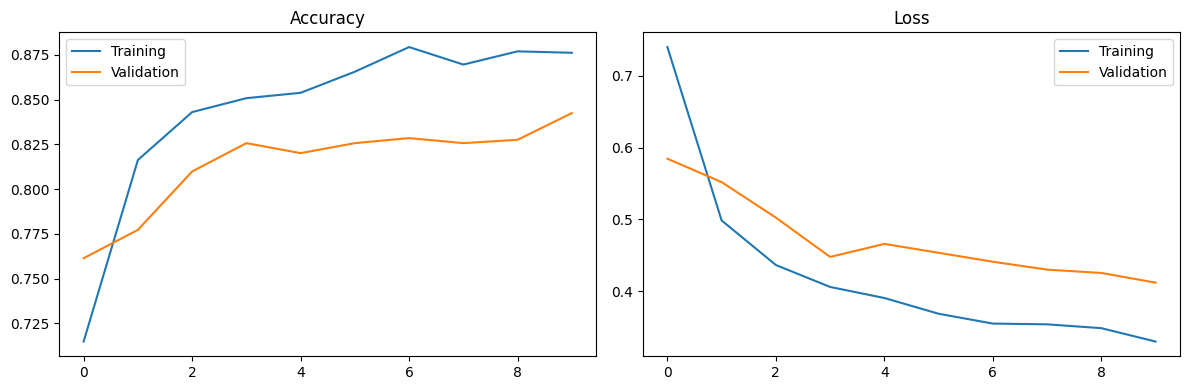

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(efficientnet_history.history["accuracy"], label="Training")
plt.plot(efficientnet_history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(efficientnet_history.history["loss"], label="Training")
plt.plot(efficientnet_history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 13. Fine-Tuning: Unfreeze the Top Layers of EfficientNetB0

In [ ]:
base_model.trainable = True

# Freeze everything except the last N layers of the base model
FINE_TUNE_AT = len(base_model.layers) - 30

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Keep BatchNormalization layers frozen even in the unfrozen block
for layer in base_model.layers[FINE_TUNE_AT:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print(f"Unfrozen layers: {sum(l.trainable for l in base_model.layers)} / {len(base_model.layers)}")

Unfrozen layers: 23 / 238


## 14. Recompile the Model with a Lower Learning Rate

In [ ]:
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 15. Continue Training (Fine-Tuning Phase)

In [ ]:
fine_tune_epochs = 10
total_epochs = len(efficientnet_history.epoch) + fine_tune_epochs

fine_tune_history = efficientnet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=total_epochs,
    initial_epoch=efficientnet_history.epoch[-1] + 1,
    class_weight=class_weights,
    callbacks=[early_stopping, model_checkpoint, reduce_lr]
)

Epoch 11/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 115ms/step - accuracy: 0.8800 - loss: 0.3192 - val_accuracy: 0.8500 - val_loss: 0.3928 - learning_rate: 1.0000e-05
Epoch 12/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step - accuracy: 0.8902 - loss: 0.3052 - val_accuracy: 0.8546 - val_loss: 0.3675 - learning_rate: 1.0000e-05
Epoch 13/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - accuracy: 0.8940 - loss: 0.2968 - val_accuracy: 0.8555 - val_loss: 0.3652 - learning_rate: 1.0000e-05
Epoch 14/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step - accuracy: 0.8972 - loss: 0.2757 - val_accuracy: 0.8555 - val_loss: 0.3589 - learning_rate: 1.0000e-05
Epoch 15/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 99ms/step - accuracy: 0.9020 - loss: 0.2737 - val_accuracy: 0.8555 - val_loss: 0.3460 - learning_rate: 1.0000e-05
Epoch 16/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.9048 - loss: 0.2654 - val_accuracy: 0.8555 - val_loss: 0.3512 - learning_rate: 1.0000e-05
Epoch 17/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 

## 16. Evaluate on the Held-Out Test Set (Fine-Tuned Model)

In [ ]:
test_loss, test_accuracy = efficientnet_model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.8706 - loss: 0.3082
Test Loss: 0.3082
Test Accuracy: 0.8706


## 17. Visualize Training History

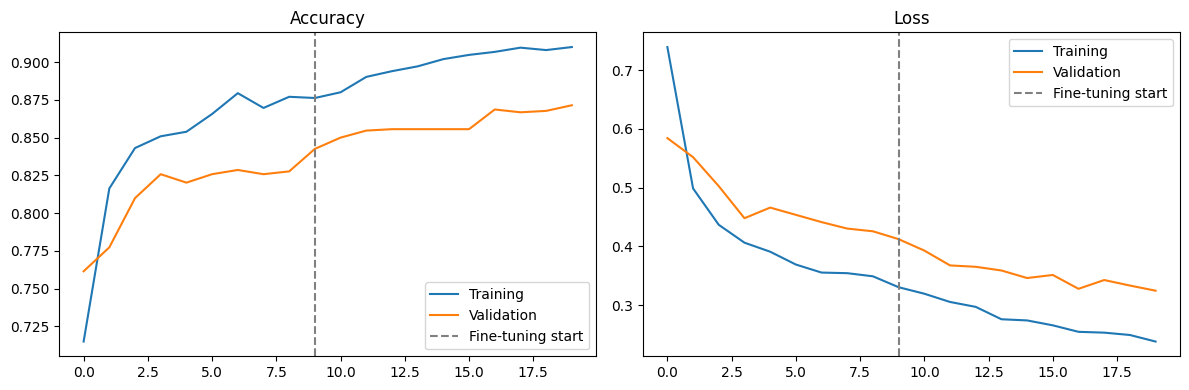

In [ ]:
acc = efficientnet_history.history["accuracy"] + fine_tune_history.history["accuracy"]
val_acc = efficientnet_history.history["val_accuracy"] + fine_tune_history.history["val_accuracy"]
loss = efficientnet_history.history["loss"] + fine_tune_history.history["loss"]
val_loss = efficientnet_history.history["val_loss"] + fine_tune_history.history["val_loss"]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(acc, label="Training")
plt.plot(val_acc, label="Validation")
plt.axvline(len(efficientnet_history.epoch) - 1, color="gray", linestyle="--", label="Fine-tuning start")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label="Training")
plt.plot(val_loss, label="Validation")
plt.axvline(len(efficientnet_history.epoch) - 1, color="gray", linestyle="--", label="Fine-tuning start")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 18. Confusion Matrix and Classification Report

34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step


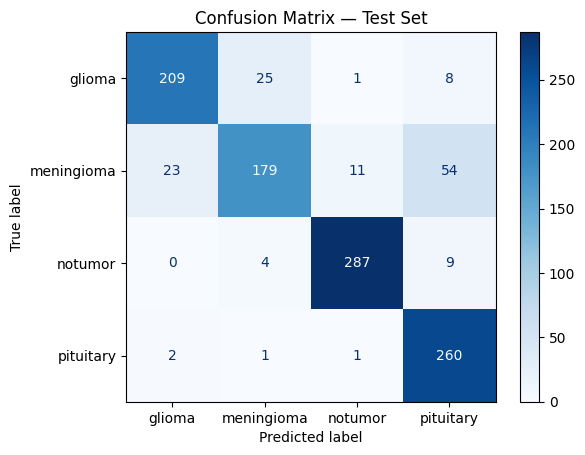

              precision    recall  f1-score   support

      glioma       0.89      0.86      0.88       243
  meningioma       0.86      0.67      0.75       267
     notumor       0.96      0.96      0.96       300
   pituitary       0.79      0.98      0.87       264

    accuracy                           0.87      1074
   macro avg       0.87      0.87      0.86      1074
weighted avg       0.88      0.87      0.87      1074



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_true = np.concatenate([labels.numpy() for _, labels in test_dataset])
y_pred_probs = efficientnet_model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Test Set")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

## 19. Save the Trained Model

In [ ]:
efficientnet_model.save('/content/drive/MyDrive/final_efficientnet_model.keras')
print("Model saved to Google Drive as final_efficientnet_model.keras")

Model saved to Google Drive as final_efficientnet_model.keras
